### Setup for Interactive Plots (Required for `plt.ginput`)

In [11]:
from google.colab import files
uploaded = files.upload()

Saving earrings.jpg to earrings (1).jpg


### Click Points (Pixel Measurement)

Earring 1
Pixel Width  = 382 px
Pixel Height = 400 px
Real Width   = 75.64 mm = 7.56 cm
Real Height  = 79.20 mm = 7.92 cm

Earring 2
Pixel Width  = 382 px
Pixel Height = 399 px
Real Width   = 75.64 mm = 7.56 cm
Real Height  = 79.00 mm = 7.90 cm



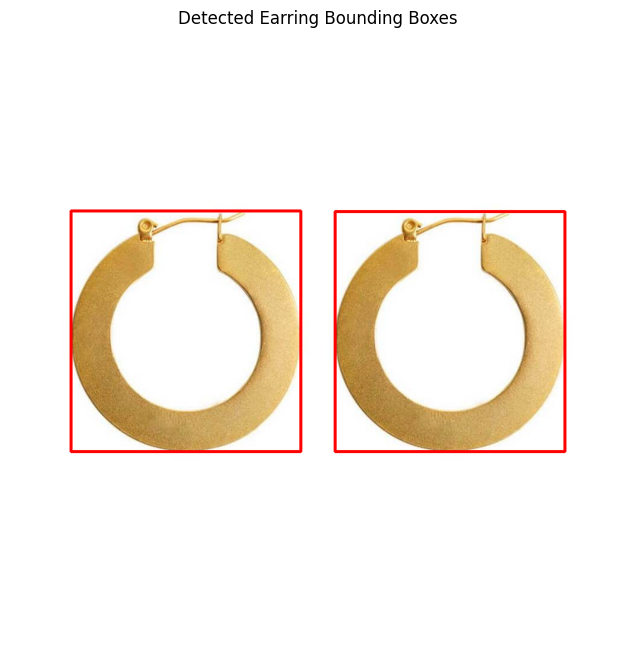

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("earrings.jpg")
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)

# Detect non-white/gold object area
mask = ((hsv[:,:,1] > 30) & (hsv[:,:,2] < 250)).astype(np.uint8) * 255

# Connected components
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, 8)

components = []
for i in range(1, num_labels):
    x, y, w, h, area = stats[i]
    if area > 1000:
        components.append((x, y, w, h, area))

# Sort left to right
components = sorted(components, key=lambda c: c[0])

pixel_size = 0.0022   # mm
distance = 720        # mm
focal_length = 8      # mm

scale = (pixel_size * distance) / focal_length

for idx, (x, y, w, h, area) in enumerate(components, start=1):
    real_w = w * scale
    real_h = h * scale

    print(f"Earring {idx}")
    print(f"Pixel Width  = {w} px")
    print(f"Pixel Height = {h} px")
    print(f"Real Width   = {real_w:.2f} mm = {real_w/10:.2f} cm")
    print(f"Real Height  = {real_h:.2f} mm = {real_h/10:.2f} cm")
    print()

    cv2.rectangle(rgb, (x,y), (x+w,y+h), (255,0,0), 3)

plt.figure(figsize=(8,8))
plt.imshow(rgb)
plt.title("Detected Earring Bounding Boxes")
plt.axis("off")
plt.show()